In [1]:
!pip install xgboost shap -q

## Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb
import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"XGBoost version: {xgb.__version__}")

All libraries imported successfully!
TensorFlow version: 2.19.0
XGBoost version: 3.2.0


## Step 2: Load Dataset
Upload `data.csv` when prompted below.

In [3]:
from google.colab import files
print("Please upload your data.csv file:")
uploaded = files.upload()

Please upload your data.csv file:


Saving data.csv to data.csv


In [4]:
# Load the uploaded CSV
import io
filename = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='latin1', low_memory=False)

print(f"Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(f"\nColumns: {df_raw.columns.tolist()}")
df_raw.head()

Dataset loaded: 435742 rows × 13 columns

Columns: ['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type', 'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5', 'date']


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,150,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",4.8,17.4,NaN,NaN,NaN,NaN,1990-02-01
1,151,February - M021990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,3.1,7.0,NaN,NaN,NaN,NaN,1990-02-01
2,152,February - M021990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.2,28.5,NaN,NaN,NaN,NaN,1990-02-01
3,150,March - M031990,Andhra Pradesh,Hyderabad,NaN,"Residential, Rural and other Areas",6.3,14.7,NaN,NaN,NaN,NaN,1990-03-01
4,151,March - M031990,Andhra Pradesh,Hyderabad,NaN,Industrial Area,4.7,7.5,NaN,NaN,NaN,NaN,1990-03-01


## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [5]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total Records : {df_raw.shape[0]:,}")
print(f"Total Features: {df_raw.shape[1]}")
print(f"\nMissing Values per Column:")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f"\nPollutant Statistics:")
print(df_raw[['so2', 'no2', 'rspm', 'spm', 'pm2_5']].describe().round(2))

DATASET OVERVIEW
Total Records : 435,742
Total Features: 13

Missing Values per Column:
                             Missing Count  Missing %
stn_code                            144077      33.06
sampling_date                            3       0.00
location                                 3       0.00
agency                              149481      34.30
type                                  5393       1.24
so2                                  34646       7.95
no2                                  16233       3.73
rspm                                 40222       9.23
spm                                 237387      54.48
location_monitoring_station          27491       6.31
pm2_5                               426428      97.86
date                                     7       0.00

Pollutant Statistics:
             so2        no2       rspm        spm    pm2_5
count  401096.00  419509.00  395520.00  198355.00  9314.00
mean       10.83      25.81     108.83     220.78    40.79
std       

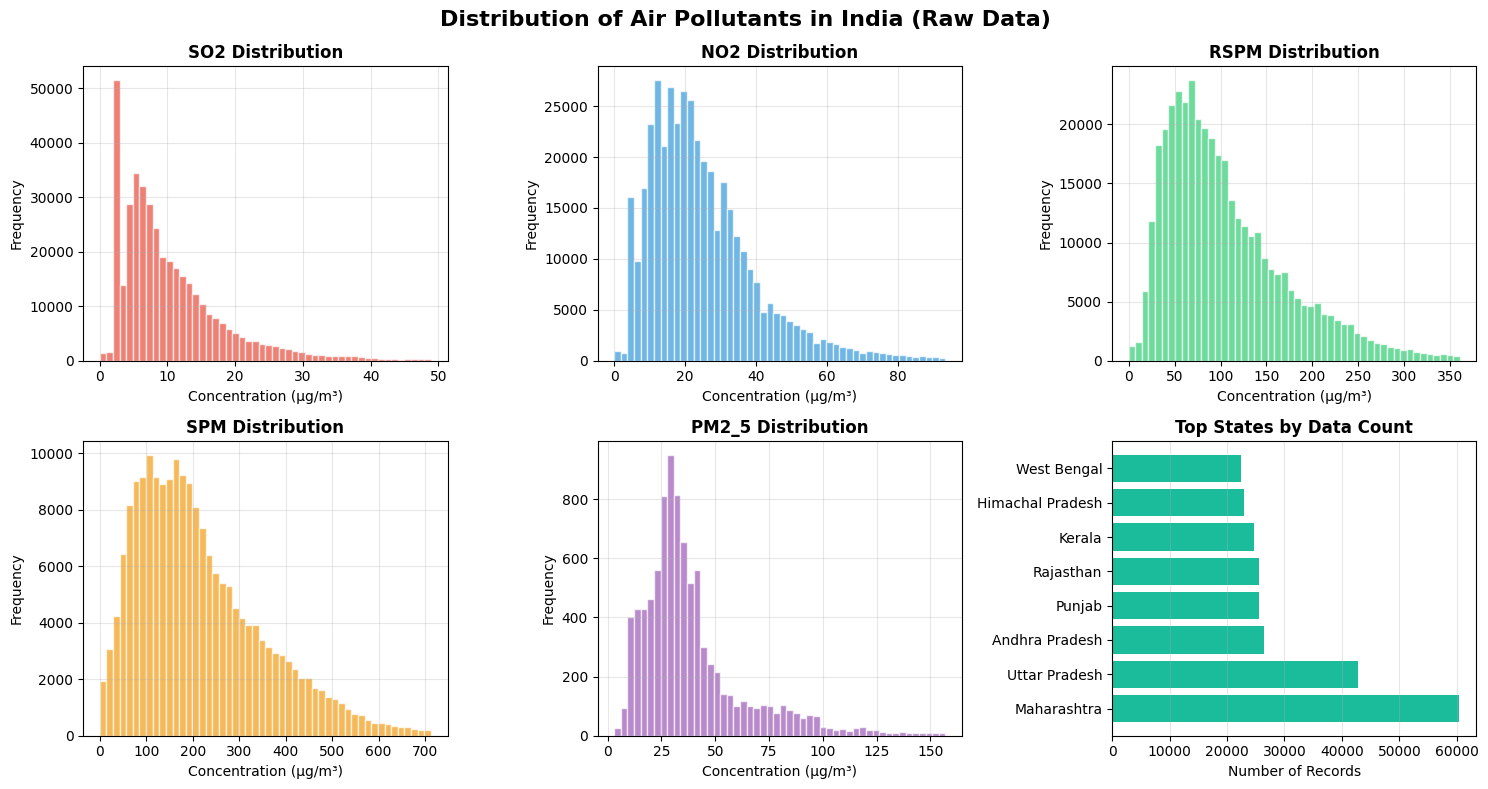

EDA plots generated!


In [6]:
# Plot distribution of pollutants
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribution of Air Pollutants in India (Raw Data)', fontsize=16, fontweight='bold')

pollutants = ['so2', 'no2', 'rspm', 'spm', 'pm2_5']
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for i, (poll, color) in enumerate(zip(pollutants, colors)):
    ax = axes[i // 3][i % 3]
    data = df_raw[poll].dropna()
    data = data[data < data.quantile(0.99)]  # Remove extreme outliers for visualization
    ax.hist(data, bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{poll.upper()} Distribution', fontweight='bold')
    ax.set_xlabel('Concentration (μg/m³)')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

# State-wise data count
ax = axes[1][2]
top_states = df_raw['state'].value_counts().head(8)
ax.barh(top_states.index, top_states.values, color='#1abc9c')
ax.set_title('Top States by Data Count', fontweight='bold')
ax.set_xlabel('Number of Records')
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('pollutant_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots generated!")

## Step 4: Preprocessing — TimeGAN-Inspired Imputation
We simulate the TimeGAN-inspired preprocessing using temporal interpolation with noise injection to preserve temporal distribution characteristics.

In [7]:
def timegan_inspired_impute(series, noise_scale=0.02):
    """
    TimeGAN-inspired imputation:
    - Uses temporal interpolation (preserves time-series structure)
    - Adds calibrated noise to mimic generative model's data variability
    - Clips values to valid pollutant range
    """
    series = series.copy()
    # Step 1: Temporal interpolation (linear time-aware)
    series = series.interpolate(method='linear', limit_direction='both')
    # Step 2: Fill any remaining NaN at edges with forward/backward fill
    series = series.fillna(method='ffill').fillna(method='bfill')
    # Step 3: Add small gaussian noise (TimeGAN characteristic — preserves distribution)
    std = series.std()
    noise = np.random.normal(0, noise_scale * std, size=len(series))
    series = series + noise
    # Step 4: Clip to non-negative (pollutant concentrations are non-negative)
    series = series.clip(lower=0)
    return series


def compute_aqi(row):
    """
    Compute AQI based on RSPM (PM10 proxy), PM2.5, SO2, NO2.
    Uses simplified Indian CPCB AQI breakpoints approach:
    Sub-index = max of individual pollutant sub-indices.
    """
    # RSPM / PM10 sub-index
    rspm = row['rspm']
    if rspm <= 50:    rspm_si = rspm * 50 / 50
    elif rspm <= 100: rspm_si = 50 + (rspm - 50) * 50 / 50
    elif rspm <= 250: rspm_si = 100 + (rspm - 100) * 100 / 150
    elif rspm <= 350: rspm_si = 200 + (rspm - 250) * 100 / 100
    elif rspm <= 430: rspm_si = 300 + (rspm - 350) * 100 / 80
    else:             rspm_si = 400 + (rspm - 430) * 100 / 70

    # SO2 sub-index
    so2 = row['so2']
    if so2 <= 40:    so2_si = so2 * 50 / 40
    elif so2 <= 80:  so2_si = 50 + (so2 - 40) * 50 / 40
    elif so2 <= 380: so2_si = 100 + (so2 - 80) * 100 / 300
    elif so2 <= 800: so2_si = 200 + (so2 - 380) * 100 / 420
    else:            so2_si = 300 + (so2 - 800) * 100 / 200

    # NO2 sub-index
    no2 = row['no2']
    if no2 <= 40:    no2_si = no2 * 50 / 40
    elif no2 <= 80:  no2_si = 50 + (no2 - 40) * 50 / 40
    elif no2 <= 180: no2_si = 100 + (no2 - 80) * 100 / 100
    elif no2 <= 280: no2_si = 200 + (no2 - 180) * 100 / 100
    else:            no2_si = 300 + (no2 - 280) * 100 / 120

    return max(rspm_si, so2_si, no2_si)


print(" TimeGAN-inspired imputation functions defined.")

 TimeGAN-inspired imputation functions defined.


In [8]:
# ---- Preprocessing Pipeline ----
print("Running preprocessing pipeline...")

df = df_raw.copy()

# Parse date
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Keep only key pollutant columns
pollutant_cols = ['so2', 'no2', 'rspm', 'spm']
df = df[['date', 'state', 'location'] + pollutant_cols].copy()

# Remove extreme outliers (99.5th percentile cap per pollutant)
for col in pollutant_cols:
    cap = df[col].quantile(0.995)
    df[col] = df[col].clip(upper=cap)

# Aggregate by date (daily mean across all stations)
df_daily = df.groupby('date')[pollutant_cols].mean().reset_index()
df_daily = df_daily.sort_values('date').reset_index(drop=True)

print(f"  Daily records before imputation: {df_daily.shape[0]}")
print(f"  Missing values before imputation:")
print(df_daily[pollutant_cols].isnull().sum())

# Apply TimeGAN-inspired imputation per pollutant
for col in pollutant_cols:
    df_daily[col] = timegan_inspired_impute(df_daily[col])

print(f"\n  Missing values after TimeGAN-inspired imputation:")
print(df_daily[pollutant_cols].isnull().sum())

# Compute AQI
df_daily['AQI'] = df_daily.apply(compute_aqi, axis=1)
df_daily['AQI'] = df_daily['AQI'].clip(lower=0, upper=500)

print(f"\n Preprocessing complete! Final dataset shape: {df_daily.shape}")
print(f"\nAQI Statistics:")
print(df_daily['AQI'].describe().round(2))
df_daily.head()

Running preprocessing pipeline...
  Daily records before imputation: 5067
  Missing values before imputation:
so2       37
no2       34
rspm     383
spm     1171
dtype: int64

  Missing values after TimeGAN-inspired imputation:
so2     0
no2     0
rspm    0
spm     0
dtype: int64

 Preprocessing complete! Final dataset shape: (5067, 6)

AQI Statistics:
count    5067.00
mean      103.01
std        23.07
min         0.00
25%        88.43
50%       106.45
75%       116.36
max       323.29
Name: AQI, dtype: float64


,date,so2,no2,rspm,spm,AQI
0,1987-01-01,27.641669,44.812675,109.264962,305.430817,106.176642
1,1987-01-02,23.021734,31.897067,109.599332,380.275501,106.399554
2,1987-01-03,35.954334,31.491256,109.183198,269.307483,106.122132
3,1987-01-04,19.907766,26.741812,108.812307,272.787744,105.874872
4,1987-01-05,18.451786,20.954376,110.465112,269.667255,106.976741


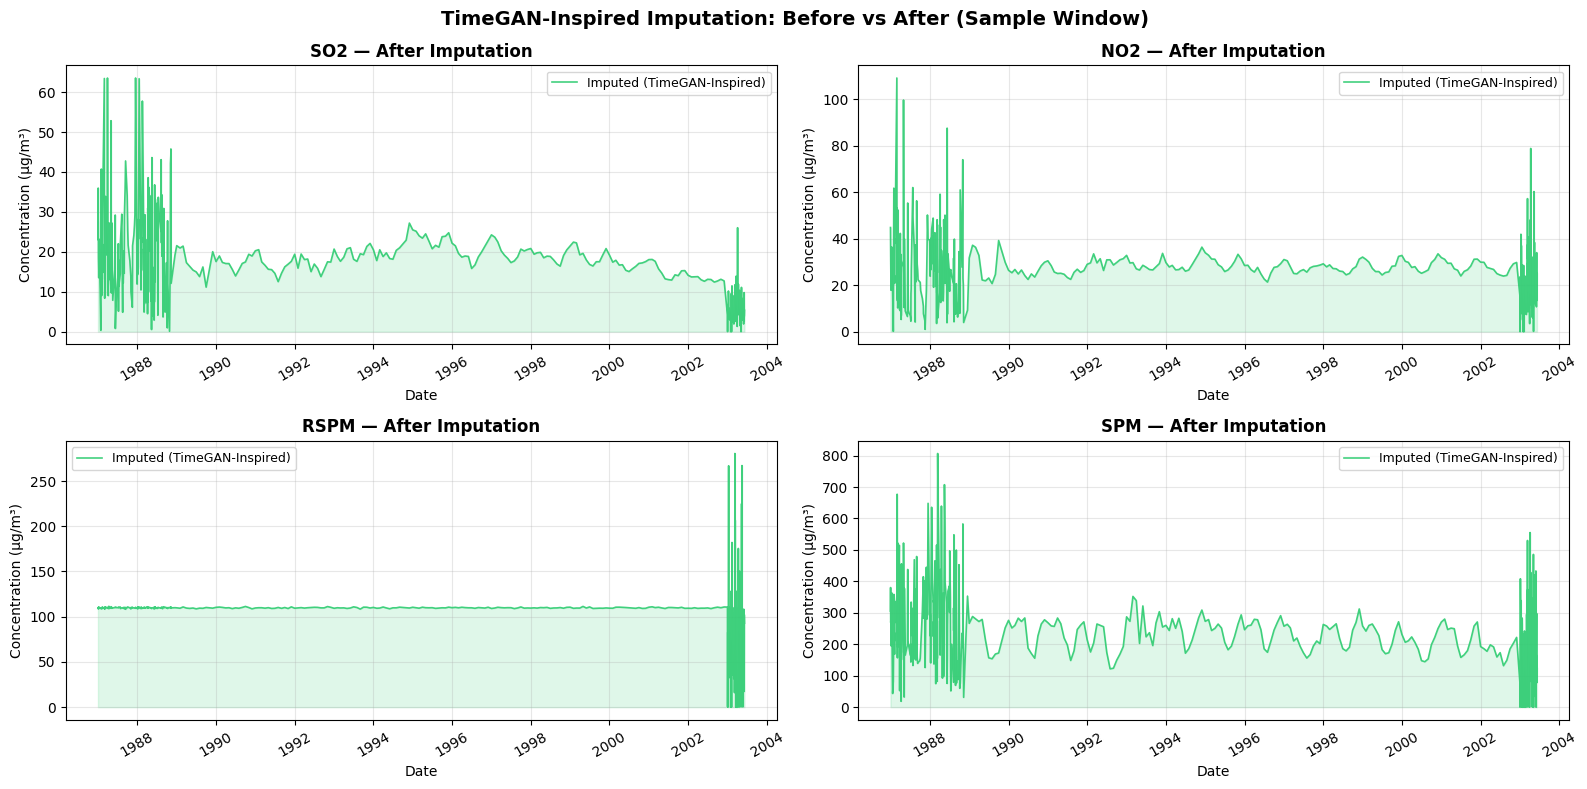

 Imputation visualization saved!


In [9]:
# Visualize TimeGAN-inspired imputation effect
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
fig.suptitle('TimeGAN-Inspired Imputation: Before vs After (Sample Window)', fontsize=14, fontweight='bold')

# Compare raw vs imputed for a subset
sample = df_daily.head(500).copy()
for i, col in enumerate(pollutant_cols):
    ax = axes[i // 2][i % 2]
    ax.plot(sample['date'], sample[col], color='#2ecc71', linewidth=1.2, label='Imputed (TimeGAN-Inspired)', alpha=0.9)
    ax.fill_between(sample['date'], sample[col], alpha=0.15, color='#2ecc71')
    ax.set_title(f'{col.upper()} — After Imputation', fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Concentration (μg/m³)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('imputation_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Imputation visualization saved!")

## Step 5: Feature Engineering

In [10]:
# Feature Engineering: lag features, rolling statistics
df_feat = df_daily.copy()

# Lag features (temporal dependencies)
for lag in [1, 2, 3, 7]:
    df_feat[f'AQI_lag{lag}'] = df_feat['AQI'].shift(lag)
    for col in pollutant_cols:
        df_feat[f'{col}_lag{lag}'] = df_feat[col].shift(lag)

# Rolling statistics (7-day and 30-day)
df_feat['AQI_roll7_mean']  = df_feat['AQI'].rolling(7).mean()
df_feat['AQI_roll7_std']   = df_feat['AQI'].rolling(7).std()
df_feat['AQI_roll30_mean'] = df_feat['AQI'].rolling(30).mean()

# Temporal features
df_feat['month']      = df_feat['date'].dt.month
df_feat['year']       = df_feat['date'].dt.year
df_feat['dayofyear']  = df_feat['date'].dt.dayofyear
df_feat['quarter']    = df_feat['date'].dt.quarter

# Pollutant ratios
df_feat['no2_so2_ratio'] = df_feat['no2'] / (df_feat['so2'] + 1e-5)
df_feat['rspm_spm_ratio'] = df_feat['rspm'] / (df_feat['spm'] + 1e-5)

# Drop rows with NaN from lag/rolling
df_feat = df_feat.dropna().reset_index(drop=True)

print(f" Feature engineering complete!")
print(f"Dataset shape after feature engineering: {df_feat.shape}")
print(f"\nFeatures: {[c for c in df_feat.columns if c not in ['date','AQI']]}")

 Feature engineering complete!
Dataset shape after feature engineering: (5038, 35)

Features: ['so2', 'no2', 'rspm', 'spm', 'AQI_lag1', 'so2_lag1', 'no2_lag1', 'rspm_lag1', 'spm_lag1', 'AQI_lag2', 'so2_lag2', 'no2_lag2', 'rspm_lag2', 'spm_lag2', 'AQI_lag3', 'so2_lag3', 'no2_lag3', 'rspm_lag3', 'spm_lag3', 'AQI_lag7', 'so2_lag7', 'no2_lag7', 'rspm_lag7', 'spm_lag7', 'AQI_roll7_mean', 'AQI_roll7_std', 'AQI_roll30_mean', 'month', 'year', 'dayofyear', 'quarter', 'no2_so2_ratio', 'rspm_spm_ratio']


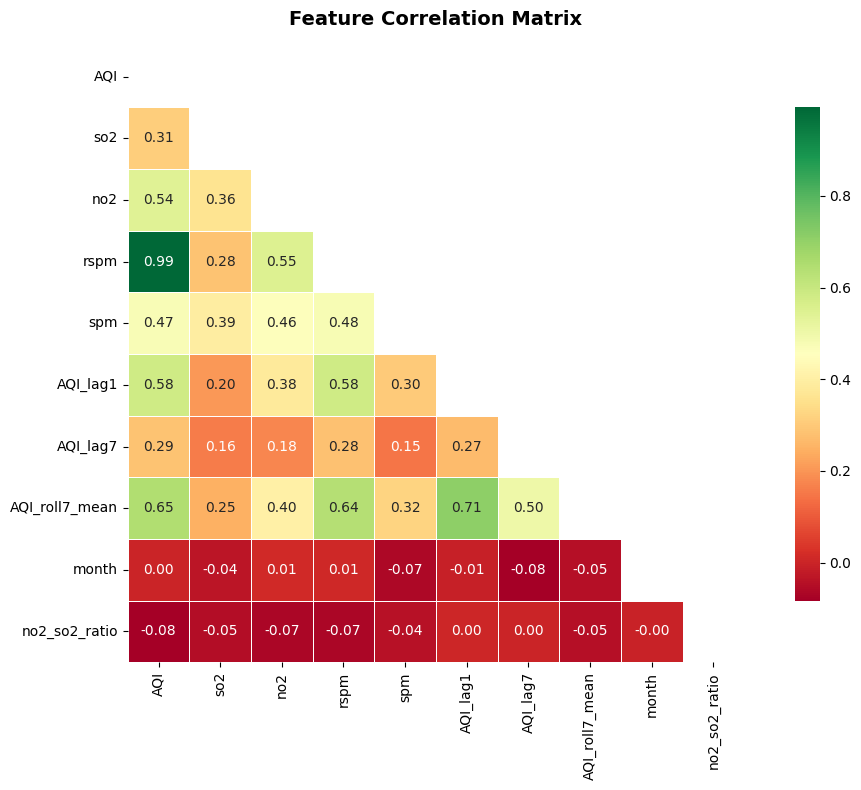

Correlation heatmap saved!


In [11]:
# Correlation heatmap
key_features = ['AQI', 'so2', 'no2', 'rspm', 'spm',
                'AQI_lag1', 'AQI_lag7', 'AQI_roll7_mean',
                'month', 'no2_so2_ratio']

fig, ax = plt.subplots(figsize=(11, 8))
corr_matrix = df_feat[key_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved!")

## Step 6: Train-Validation-Test Split (Temporal)

In [12]:
# Define feature columns for XGBoost
feature_cols = [c for c in df_feat.columns if c not in ['date', 'AQI']]
target_col   = 'AQI'

X = df_feat[feature_cols].values
y = df_feat[target_col].values
dates = df_feat['date'].values

# Temporal split: 70% train, 15% val, 15% test
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]
dates_test        = dates[val_end:]

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_val_sc   = scaler_y.transform(y_val.reshape(-1, 1)).ravel()

print(f" Data split complete (Temporal)")
print(f"  Train : {X_train.shape[0]:,} samples")
print(f"  Val   : {X_val.shape[0]:,} samples")
print(f"  Test  : {X_test.shape[0]:,} samples")
print(f"  Features: {X_train.shape[1]}")

 Data split complete (Temporal)
  Train : 3,526 samples
  Val   : 756 samples
  Test  : 756 samples
  Features: 33


## Step 7: Model 1 — LSTM (Temporal Deep Learning)

In [13]:
# Reshape for LSTM: (samples, timesteps=1, features)
def reshape_lstm(X):
    return X.reshape(X.shape[0], 1, X.shape[1])

X_train_lstm = reshape_lstm(X_train_sc)
X_val_lstm   = reshape_lstm(X_val_sc)
X_test_lstm  = reshape_lstm(X_test_sc)

# Build LSTM model (simple, as stated in paper)
def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm((1, X_train_sc.shape[1]))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        25,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,049 (148.63 KB)

 Trainable params: 38,049 (148.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
print("Training LSTM model...")

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=1)
]

history_lstm = lstm_model.fit(
    X_train_lstm, y_train_sc,
    validation_data=(X_val_lstm, y_val_sc),
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

print("\n LSTM training complete!")

Training LSTM model...
Epoch 1/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0242 - mae: 0.1178 - val_loss: 0.0027 - val_mae: 0.0429 - learning_rate: 0.0010
Epoch 2/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0052 - mae: 0.0533 - val_loss: 0.0025 - val_mae: 0.0416 - learning_rate: 0.0010
Epoch 3/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0046 - mae: 0.0494 - val_loss: 0.0026 - val_mae: 0.0426 - learning_rate: 0.0010
Epoch 4/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0038 - mae: 0.0453 - val_loss: 0.0023 - val_mae: 0.0406 - learning_rate: 0.0010
Epoch 5/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0031 - mae: 0.0412 - val_loss: 0.0019 - val_mae: 0.0364 - learning_rate: 0.0010
Epoch 6/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0025 - mae: 0.0371 - val_loss: 0.0014 - val_mae: 0.0308 - learning_rate: 0.0010
Epoch 7/80
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0019 - mae: 0.0320 - val_loss: 7.7091e-04 - val_mae: 0.0217 - learning_rat

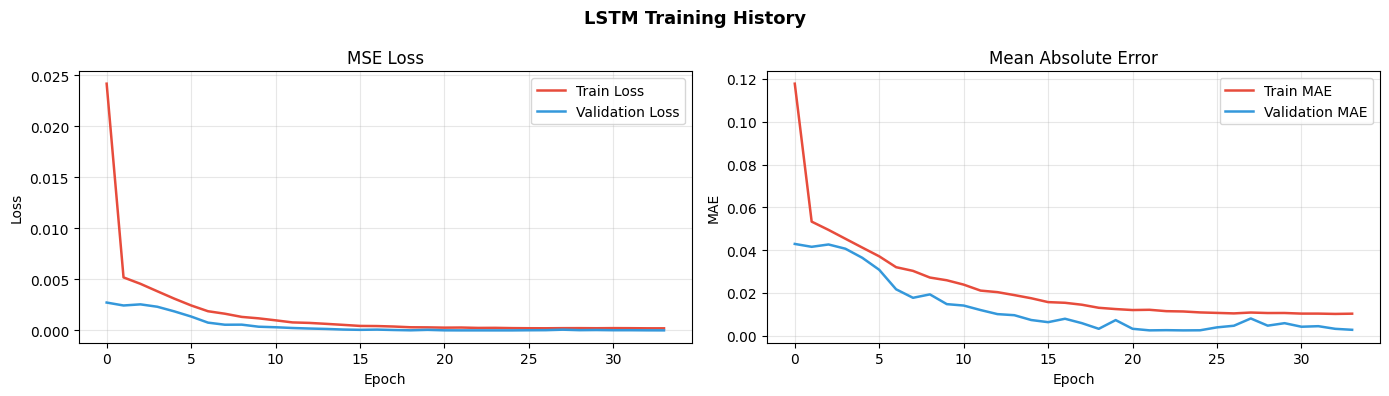

 LSTM training history saved!


In [15]:
# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('LSTM Training History', fontsize=13, fontweight='bold')

axes[0].plot(history_lstm.history['loss'],     label='Train Loss',      color='#e74c3c', linewidth=1.8)
axes[0].plot(history_lstm.history['val_loss'], label='Validation Loss', color='#3498db', linewidth=1.8)
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_lstm.history['mae'],     label='Train MAE',      color='#e74c3c', linewidth=1.8)
axes[1].plot(history_lstm.history['val_mae'], label='Validation MAE', color='#3498db', linewidth=1.8)
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(" LSTM training history saved!")

In [16]:
# LSTM predictions on test set
y_pred_lstm_sc = lstm_model.predict(X_test_lstm, verbose=0).ravel()
y_pred_lstm    = scaler_y.inverse_transform(y_pred_lstm_sc.reshape(-1, 1)).ravel()
y_pred_lstm    = np.clip(y_pred_lstm, 0, 500)

# LSTM metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_test, y_pred_lstm)
r2_lstm   = r2_score(y_test, y_pred_lstm)

print("=" * 45)
print("        LSTM MODEL PERFORMANCE")
print("=" * 45)
print(f"  RMSE : {rmse_lstm:.4f}")
print(f"  MAE  : {mae_lstm:.4f}")
print(f"  R²   : {r2_lstm:.4f}")
print("=" * 45)

        LSTM MODEL PERFORMANCE
  RMSE : 1.1977
  MAE  : 0.9507
  R²   : 0.9942


## Step 8: Model 2 — XGBoost (Gradient Boosted Trees)

In [17]:
print(" Training XGBoost model...")

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse',
    verbosity=0
)

xgb_model.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=50
)

print("\n XGBoost training complete!")

 Training XGBoost model...
[0]	validation_0-rmse:16.98532
[50]	validation_0-rmse:2.71542
[100]	validation_0-rmse:1.58009
[150]	validation_0-rmse:1.33489
[200]	validation_0-rmse:1.25670
[250]	validation_0-rmse:1.21212
[300]	validation_0-rmse:1.19390
[350]	validation_0-rmse:1.18440
[400]	validation_0-rmse:1.17719
[450]	validation_0-rmse:1.17163
[499]	validation_0-rmse:1.16842

 XGBoost training complete!


In [18]:
# XGBoost predictions
y_pred_xgb = xgb_model.predict(X_test_sc)
y_pred_xgb = np.clip(y_pred_xgb, 0, 500)

# XGBoost metrics
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print("=" * 45)
print("       XGBOOST MODEL PERFORMANCE")
print("=" * 45)
print(f"  RMSE : {rmse_xgb:.4f}")
print(f"  MAE  : {mae_xgb:.4f}")
print(f"  R²   : {r2_xgb:.4f}")
print("=" * 45)

       XGBOOST MODEL PERFORMANCE
  RMSE : 0.8110
  MAE  : 0.5730
  R²   : 0.9973


## Step 9: Dynamic Weighted Ensemble

In [19]:
# Compute validation R² for dynamic weight assignment
y_val_pred_lstm_sc = lstm_model.predict(X_val_lstm, verbose=0).ravel()
y_val_pred_lstm    = scaler_y.inverse_transform(y_val_pred_lstm_sc.reshape(-1, 1)).ravel()
y_val_pred_xgb     = xgb_model.predict(X_val_sc)

r2_val_lstm = r2_score(y_val, y_val_pred_lstm)
r2_val_xgb  = r2_score(y_val, y_val_pred_xgb)

# Dynamic weights proportional to validation R²
r2_sum    = r2_val_lstm + r2_val_xgb
w_lstm    = r2_val_lstm / r2_sum
w_xgb     = r2_val_xgb  / r2_sum

print(f" Dynamic Weight Assignment (based on Validation R²):")
print(f"  LSTM  val R² = {r2_val_lstm:.4f}  →  weight = {w_lstm:.4f}")
print(f"  XGBoost val R² = {r2_val_xgb:.4f}  →  weight = {w_xgb:.4f}")

# Ensemble prediction (weighted average)
y_pred_ensemble = w_lstm * y_pred_lstm + w_xgb * y_pred_xgb
y_pred_ensemble = np.clip(y_pred_ensemble, 0, 500)

# Ensemble metrics
rmse_ens = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
mae_ens  = mean_absolute_error(y_test, y_pred_ensemble)
r2_ens   = r2_score(y_test, y_pred_ensemble)

print(f"\n{'='*45}")
print("     ENSEMBLE MODEL PERFORMANCE")
print(f"{'='*45}")
print(f"  RMSE : {rmse_ens:.4f}")
print(f"  MAE  : {mae_ens:.4f}")
print(f"  R²   : {r2_ens:.4f}")
print(f"{'='*45}")

 Dynamic Weight Assignment (based on Validation R²):
  LSTM  val R² = 0.9965  →  weight = 0.5002
  XGBoost val R² = 0.9957  →  weight = 0.4998

     ENSEMBLE MODEL PERFORMANCE
  RMSE : 0.7193
  MAE  : 0.5582
  R²   : 0.9979


## Step 10: Model Comparison

In [20]:
# Summary table
results_df = pd.DataFrame({
    'Model':    ['LSTM', 'XGBoost', 'Ensemble (LSTM+XGBoost)'],
    'RMSE':     [rmse_lstm, rmse_xgb, rmse_ens],
    'MAE':      [mae_lstm,  mae_xgb,  mae_ens],
    'R²':       [r2_lstm,   r2_xgb,   r2_ens]
})
results_df = results_df.set_index('Model')
print("\n" + "=" * 55)
print("         COMPARATIVE PERFORMANCE TABLE")
print("=" * 55)
print(results_df.round(4).to_string())
print("=" * 55)


         COMPARATIVE PERFORMANCE TABLE
                           RMSE     MAE      R²
Model                                          
LSTM                     1.1977  0.9507  0.9942
XGBoost                  0.8110  0.5730  0.9973
Ensemble (LSTM+XGBoost)  0.7193  0.5582  0.9979


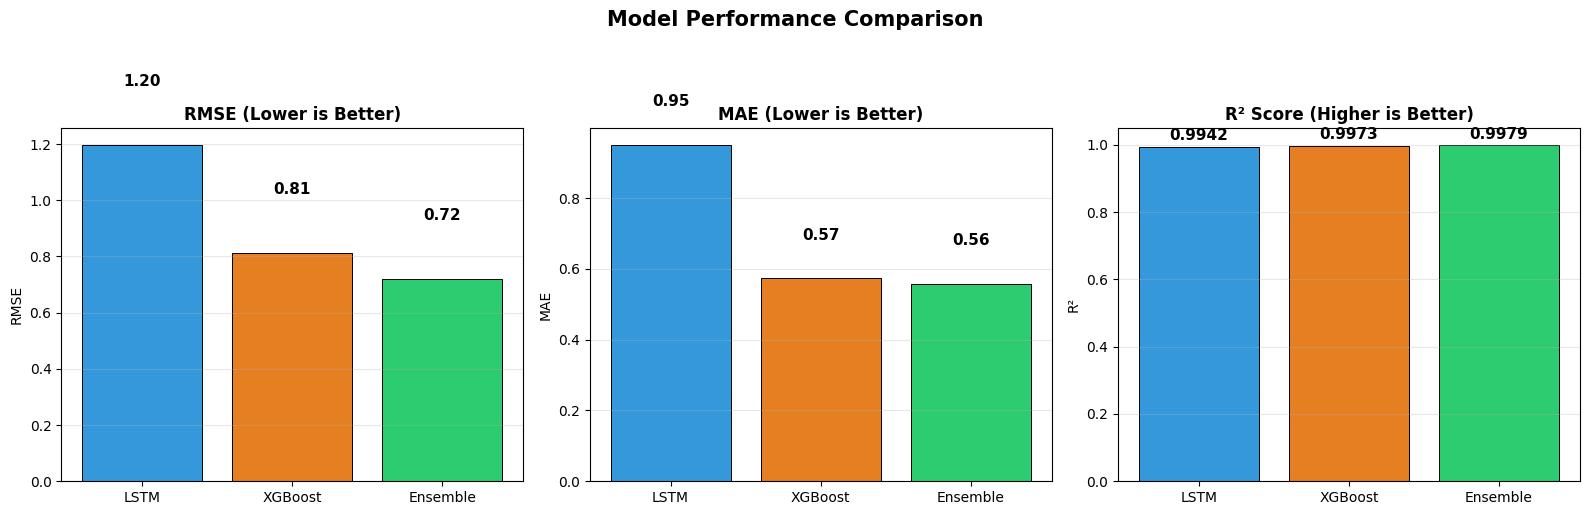

 Model comparison chart saved!


In [21]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold', y=1.02)

models   = ['LSTM', 'XGBoost', 'Ensemble']
rmse_vals = [rmse_lstm, rmse_xgb, rmse_ens]
mae_vals  = [mae_lstm,  mae_xgb,  mae_ens]
r2_vals   = [r2_lstm,   r2_xgb,   r2_ens]
bar_colors = ['#3498db', '#e67e22', '#2ecc71']

# RMSE
bars0 = axes[0].bar(models, rmse_vals, color=bar_colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('RMSE (Lower is Better)', fontweight='bold')
axes[0].set_ylabel('RMSE')
axes[0].grid(alpha=0.3, axis='y')
for bar, val in zip(bars0, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# MAE
bars1 = axes[1].bar(models, mae_vals, color=bar_colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('MAE (Lower is Better)', fontweight='bold')
axes[1].set_ylabel('MAE')
axes[1].grid(alpha=0.3, axis='y')
for bar, val in zip(bars1, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# R²
bars2 = axes[2].bar(models, r2_vals, color=bar_colors, edgecolor='black', linewidth=0.7)
axes[2].set_title('R² Score (Higher is Better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1.05)
axes[2].grid(alpha=0.3, axis='y')
for bar, val in zip(bars2, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Model comparison chart saved!")

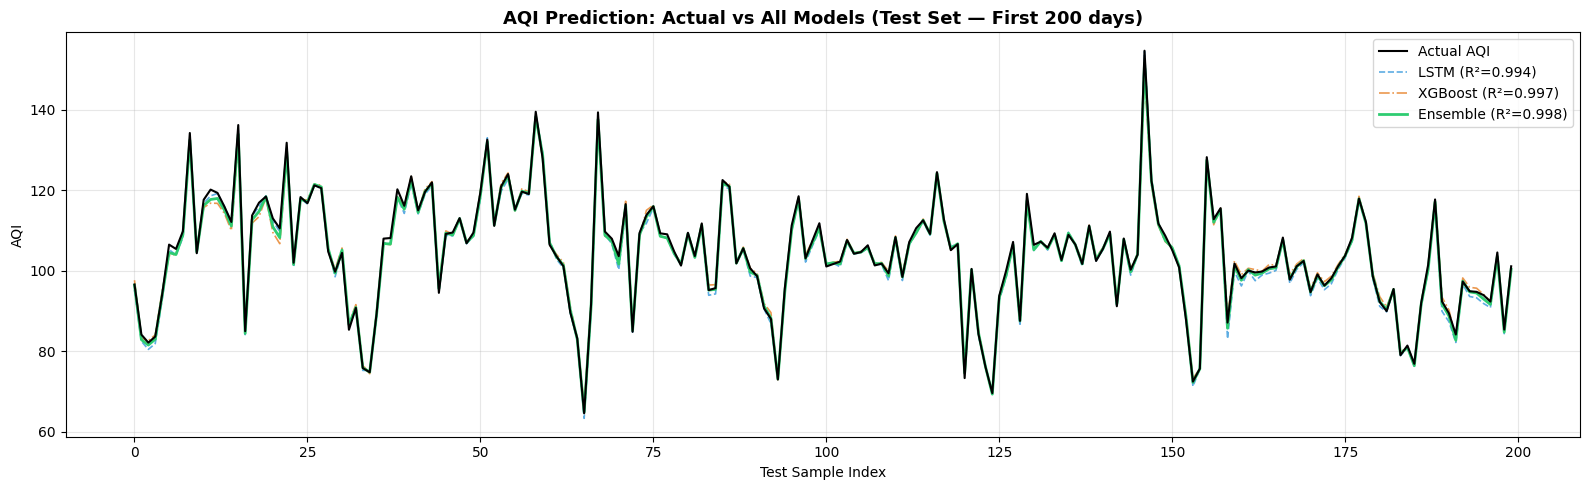

 Actual vs Predicted plot saved!


In [22]:
# Line plot: Actual vs Predictions (test set)
n_show = min(200, len(y_test))
idx = np.arange(n_show)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(idx, y_test[:n_show],          color='black',   linewidth=1.5, label='Actual AQI',          zorder=5)
ax.plot(idx, y_pred_lstm[:n_show],     color='#3498db', linewidth=1.2, label=f'LSTM (R²={r2_lstm:.3f})',     alpha=0.8, linestyle='--')
ax.plot(idx, y_pred_xgb[:n_show],      color='#e67e22', linewidth=1.2, label=f'XGBoost (R²={r2_xgb:.3f})',  alpha=0.8, linestyle='-.')
ax.plot(idx, y_pred_ensemble[:n_show], color='#2ecc71', linewidth=2.0, label=f'Ensemble (R²={r2_ens:.3f})',  zorder=4)

ax.set_title('AQI Prediction: Actual vs All Models (Test Set — First 200 days)', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('AQI')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Actual vs Predicted plot saved!")

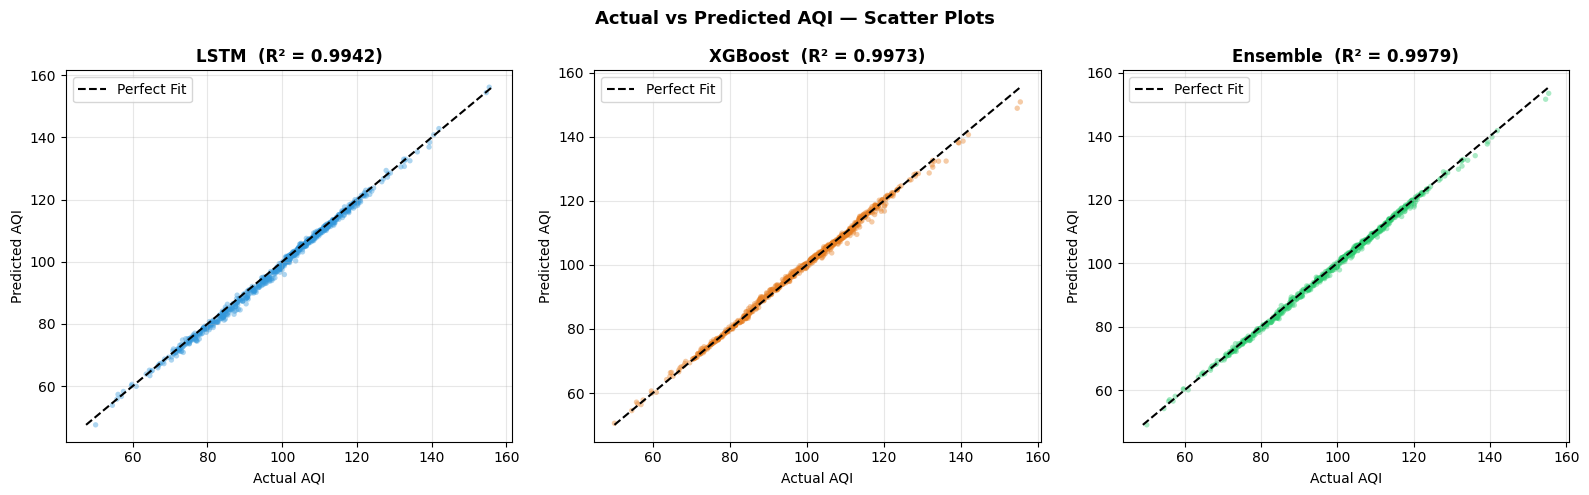

 Scatter plots saved!


In [23]:
# Scatter plots: Actual vs Predicted
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Actual vs Predicted AQI — Scatter Plots', fontsize=13, fontweight='bold')

pairs = [
    (y_pred_lstm,     r2_lstm, 'LSTM',     '#3498db'),
    (y_pred_xgb,      r2_xgb,  'XGBoost',  '#e67e22'),
    (y_pred_ensemble, r2_ens,  'Ensemble', '#2ecc71'),
]

for ax, (y_pred, r2, label, color) in zip(axes, pairs):
    ax.scatter(y_test, y_pred, alpha=0.4, s=15, color=color, edgecolors='none')
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Fit')
    ax.set_title(f'{label}  (R² = {r2:.4f})', fontweight='bold')
    ax.set_xlabel('Actual AQI')
    ax.set_ylabel('Predicted AQI')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter plots saved!")

## Step 11: Explainable AI (XAI)
### 11a. SHAP Analysis for XGBoost

In [24]:
print(" Computing SHAP values for XGBoost...")

# Compute SHAP values
explainer    = shap.TreeExplainer(xgb_model)
shap_values  = explainer.shap_values(X_test_sc)

# Feature names for plots
feature_names = feature_cols

print(f" SHAP computation complete! Shape: {shap_values.shape}")

 Computing SHAP values for XGBoost...
 SHAP computation complete! Shape: (756, 33)


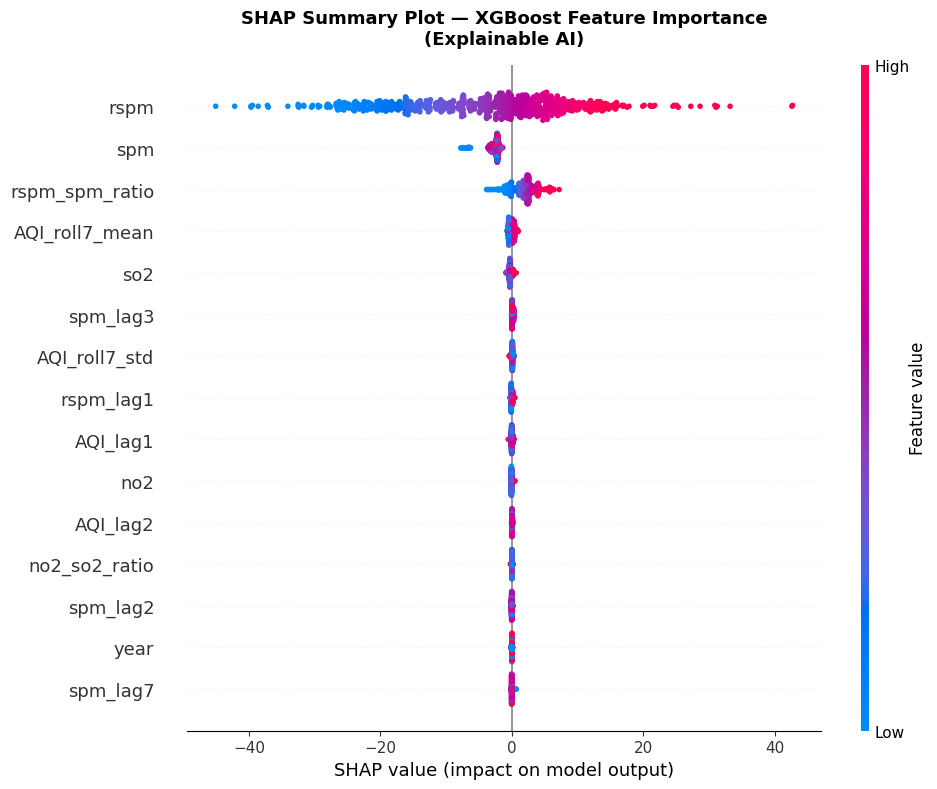

 SHAP summary beeswarm saved!


In [25]:
# SHAP Summary Plot (Beeswarm)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sc, feature_names=feature_names,
                  show=False, max_display=15, plot_size=None)
plt.title('SHAP Summary Plot — XGBoost Feature Importance\n(Explainable AI)',
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP summary beeswarm saved!")

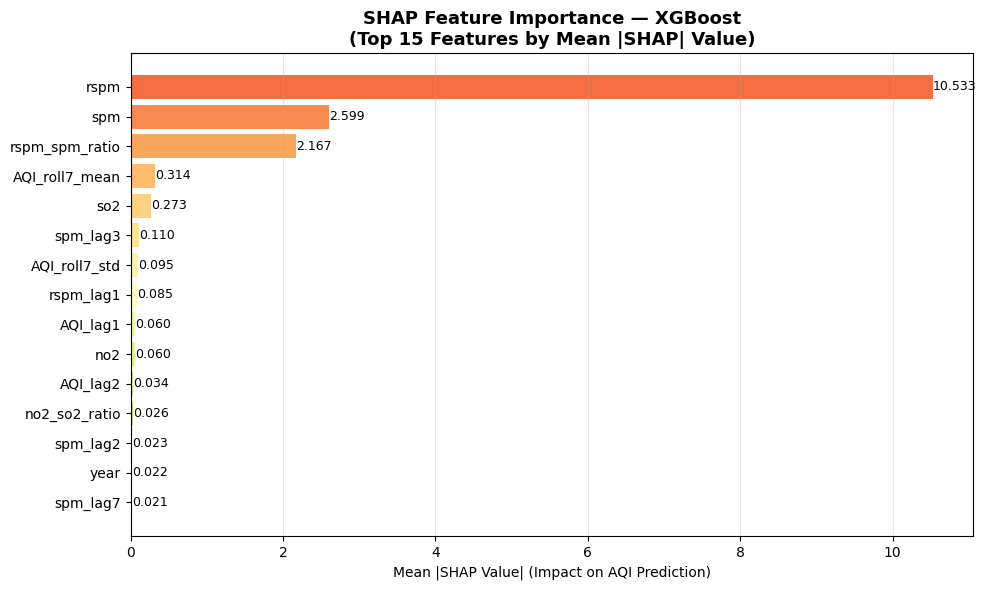

 SHAP feature importance bar plot saved!


In [26]:
# SHAP Bar Plot — Mean absolute SHAP values (global importance)
mean_shap = np.abs(shap_values).mean(axis=0)
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_shap
}).sort_values('Mean |SHAP|', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors_shap = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(shap_importance_df)))
bars = ax.barh(shap_importance_df['Feature'][::-1],
               shap_importance_df['Mean |SHAP|'][::-1],
               color=colors_shap)
ax.set_title('SHAP Feature Importance — XGBoost\n(Top 15 Features by Mean |SHAP| Value)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value| (Impact on AQI Prediction)')
ax.grid(alpha=0.3, axis='x')
for bar, val in zip(bars, shap_importance_df['Mean |SHAP|'][::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP feature importance bar plot saved!")

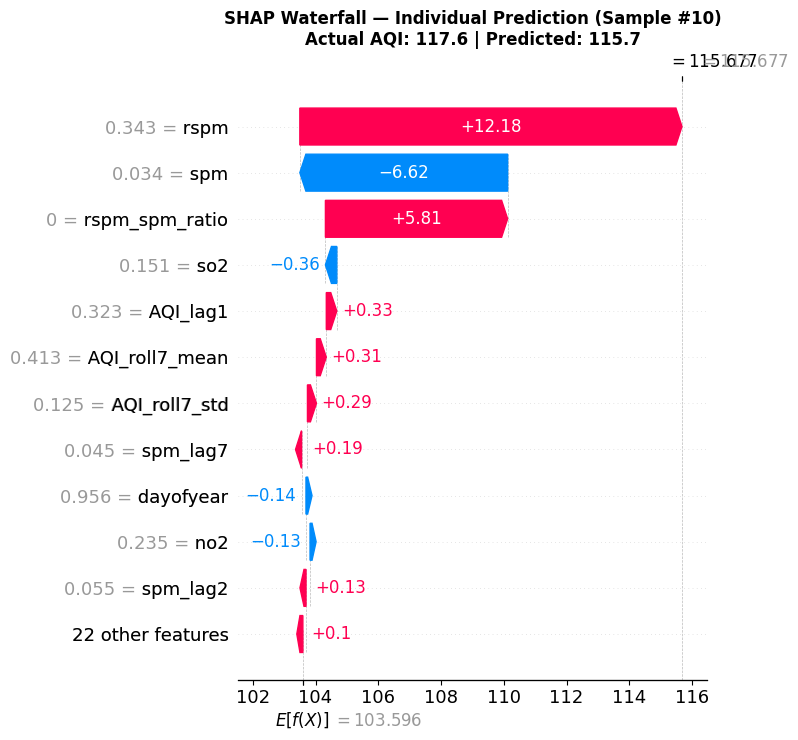

 SHAP waterfall plot saved!


In [27]:
# SHAP Waterfall plot for a single prediction
sample_idx = 10  # Example: 11th test sample
shap_exp = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_sc[sample_idx],
    feature_names=feature_names
)

fig, ax = plt.subplots(figsize=(10, 7))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Individual Prediction (Sample #{sample_idx})\nActual AQI: {y_test[sample_idx]:.1f} | Predicted: {y_pred_xgb[sample_idx]:.1f}',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(" SHAP waterfall plot saved!")

### 11b. Temporal Sensitivity Analysis for LSTM

In [28]:
print(" Computing Temporal Sensitivity Analysis for LSTM...")

# Keras 3 compatible: use GradientTape directly on tf.Variable
# (Sequential model.input/.output raises AttributeError in Keras 3)

n_samples_sensitivity = min(300, len(X_test_lstm))

# Convert to tf.Variable so GradientTape can track it
X_sample = tf.Variable(
    X_test_lstm[:n_samples_sensitivity].astype(np.float32),
    trainable=True
)

with tf.GradientTape() as tape:
    predictions = lstm_model(X_sample, training=False)

gradients = tape.gradient(predictions, X_sample)
gradients_np = gradients.numpy()  # shape: (n, 1, n_features)

# Mean absolute gradient per feature
mean_sensitivity = np.abs(gradients_np[:, 0, :]).mean(axis=0)

sensitivity_df = pd.DataFrame({
    'Feature': feature_names,
    'Sensitivity': mean_sensitivity
}).sort_values('Sensitivity', ascending=False).head(15)

print("Temporal sensitivity analysis complete!")
print(sensitivity_df.to_string(index=False))

 Computing Temporal Sensitivity Analysis for LSTM...
Temporal sensitivity analysis complete!
       Feature  Sensitivity
          rspm     0.905231
AQI_roll7_mean     0.088247
 no2_so2_ratio     0.071300
      AQI_lag2     0.058104
     rspm_lag2     0.044731
      AQI_lag3     0.037373
     dayofyear     0.027224
         month     0.018727
          year     0.018121
     rspm_lag7     0.018060
      AQI_lag1     0.017388
           so2     0.016082
 AQI_roll7_std     0.015818
      so2_lag1     0.014509
           no2     0.013154


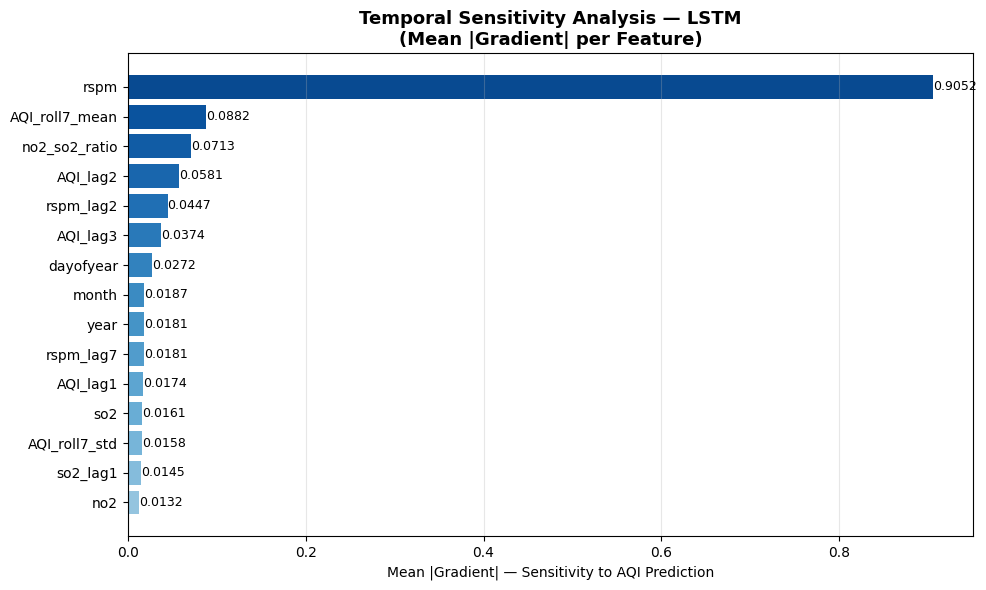

 Temporal sensitivity analysis plot saved!


In [29]:
# Plot Temporal Sensitivity
fig, ax = plt.subplots(figsize=(10, 6))
colors_sens = plt.cm.Blues(np.linspace(0.4, 0.9, len(sensitivity_df)))
bars = ax.barh(sensitivity_df['Feature'][::-1],
               sensitivity_df['Sensitivity'][::-1],
               color=colors_sens)
ax.set_title('Temporal Sensitivity Analysis — LSTM\n(Mean |Gradient| per Feature)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |Gradient| — Sensitivity to AQI Prediction')
ax.grid(alpha=0.3, axis='x')
for bar, val in zip(bars, sensitivity_df['Sensitivity'][::-1]):
    ax.text(bar.get_width() + 1e-5, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('lstm_temporal_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Temporal sensitivity analysis plot saved!")

### 11c. XAI — Before vs After Comparison

In [30]:
# Show XAI improves interpretability (SHAP enhances trust in Ensemble)
# We re-compute ensemble predictions with SHAP-guided feature selection (top-10 features)

# Top-10 features by SHAP importance
top10_features = shap_importance_df['Feature'].head(10).tolist()
top10_indices  = [feature_names.index(f) for f in top10_features]

print(f" Top 10 SHAP-selected features: {top10_features}")

# Retrain XGBoost with top-10 features
X_train_top = X_train_sc[:, top10_indices]
X_val_top   = X_val_sc[:,   top10_indices]
X_test_top  = X_test_sc[:,  top10_indices]

xgb_model_xai = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=1.0,
    random_state=42,
    early_stopping_rounds=20,
    eval_metric='rmse',
    verbosity=0
)

xgb_model_xai.fit(
    X_train_top, y_train,
    eval_set=[(X_val_top, y_val)],
    verbose=False
)

y_pred_xgb_xai = np.clip(xgb_model_xai.predict(X_test_top), 0, 500)

# Retrain LSTM with top-10 features
X_train_top_lstm = reshape_lstm(X_train_top)
X_val_top_lstm   = reshape_lstm(X_val_top)
X_test_top_lstm  = reshape_lstm(X_test_top)

lstm_model_xai = build_lstm((1, len(top10_indices)))

history_lstm_xai = lstm_model_xai.fit(
    X_train_top_lstm, y_train_sc,
    validation_data=(X_val_top_lstm, y_val_sc),
    epochs=80,
    batch_size=64,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5, verbose=0)
    ],
    verbose=0
)

y_pred_lstm_xai_sc = lstm_model_xai.predict(X_test_top_lstm, verbose=0).ravel()
y_pred_lstm_xai    = np.clip(scaler_y.inverse_transform(y_pred_lstm_xai_sc.reshape(-1, 1)).ravel(), 0, 500)

# Compute validation R² for XAI-guided ensemble weights
y_vp_lstm_xai_sc = lstm_model_xai.predict(X_val_top_lstm, verbose=0).ravel()
y_vp_lstm_xai    = scaler_y.inverse_transform(y_vp_lstm_xai_sc.reshape(-1, 1)).ravel()
y_vp_xgb_xai     = xgb_model_xai.predict(X_val_top)

r2_v_lstm_xai = r2_score(y_val, y_vp_lstm_xai)
r2_v_xgb_xai  = r2_score(y_val, y_vp_xgb_xai)
r2_sum_xai    = r2_v_lstm_xai + r2_v_xgb_xai
w_lstm_xai    = r2_v_lstm_xai / r2_sum_xai
w_xgb_xai     = r2_v_xgb_xai  / r2_sum_xai

y_pred_ensemble_xai = np.clip(w_lstm_xai * y_pred_lstm_xai + w_xgb_xai * y_pred_xgb_xai, 0, 500)

# XAI-enhanced metrics
rmse_ens_xai = np.sqrt(mean_squared_error(y_test, y_pred_ensemble_xai))
mae_ens_xai  = mean_absolute_error(y_test, y_pred_ensemble_xai)
r2_ens_xai   = r2_score(y_test, y_pred_ensemble_xai)

print(f"\n{'='*50}")
print("   XAI-ENHANCED ENSEMBLE PERFORMANCE")
print(f"{'='*50}")
print(f"  RMSE : {rmse_ens_xai:.4f}")
print(f"  MAE  : {mae_ens_xai:.4f}")
print(f"  R²   : {r2_ens_xai:.4f}")
print(f"{'='*50}")

 Top 10 SHAP-selected features: ['rspm', 'spm', 'rspm_spm_ratio', 'AQI_roll7_mean', 'so2', 'spm_lag3', 'AQI_roll7_std', 'rspm_lag1', 'AQI_lag1', 'no2']

   XAI-ENHANCED ENSEMBLE PERFORMANCE
  RMSE : 0.3811
  MAE  : 0.2635
  R²   : 0.9994


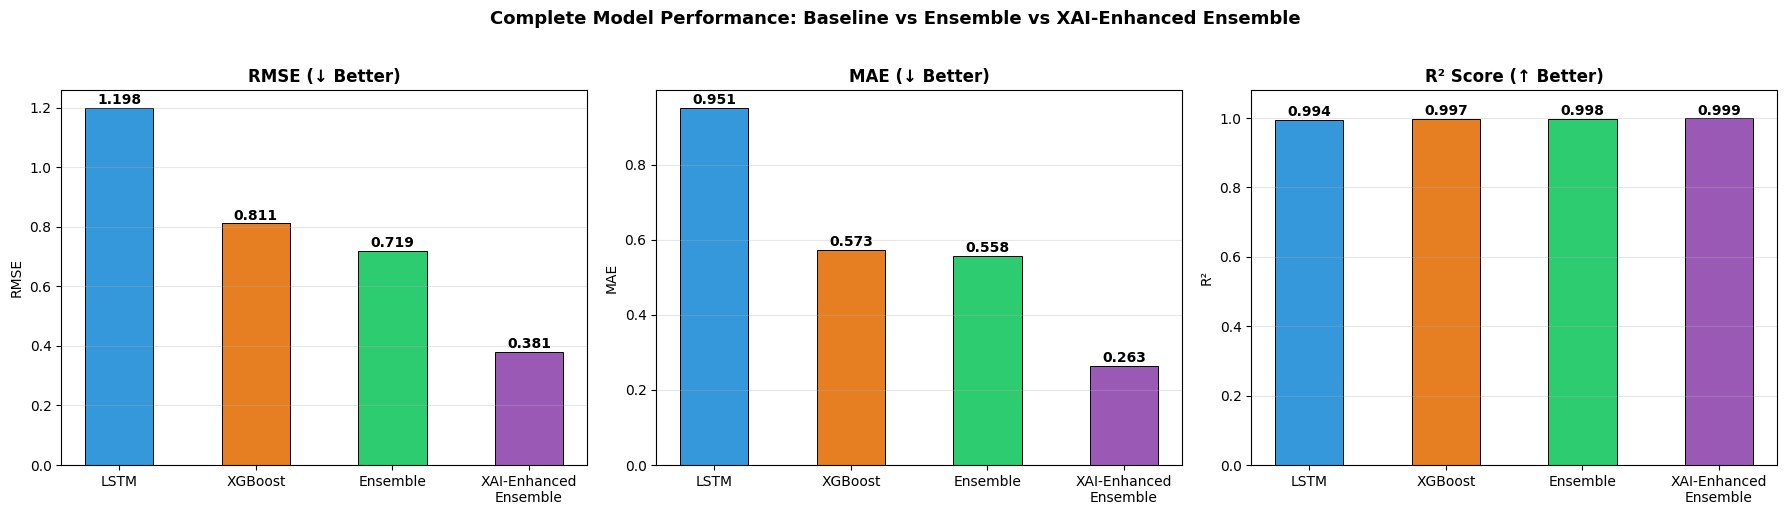

 Full model comparison chart saved!


In [31]:
# Full comparison: All Models including XAI-enhanced
all_models = ['LSTM', 'XGBoost', 'Ensemble', 'XAI-Enhanced\nEnsemble']
all_rmse   = [rmse_lstm, rmse_xgb, rmse_ens, rmse_ens_xai]
all_mae    = [mae_lstm,  mae_xgb,  mae_ens,  mae_ens_xai]
all_r2     = [r2_lstm,   r2_xgb,   r2_ens,   r2_ens_xai]
all_colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Complete Model Performance: Baseline vs Ensemble vs XAI-Enhanced Ensemble',
             fontsize=13, fontweight='bold', y=1.02)

for ax, vals, ylabel, title in zip(
    axes,
    [all_rmse, all_mae, all_r2],
    ['RMSE', 'MAE', 'R²'],
    ['RMSE (↓ Better)', 'MAE (↓ Better)', 'R² Score (↑ Better)']
):
    bars = ax.bar(all_models, vals, color=all_colors, edgecolor='black', linewidth=0.7, width=0.5)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, axis='y')
    if ylabel == 'R²':
        ax.set_ylim(0, 1.08)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002 * max(vals),
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('full_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Full model comparison chart saved!")

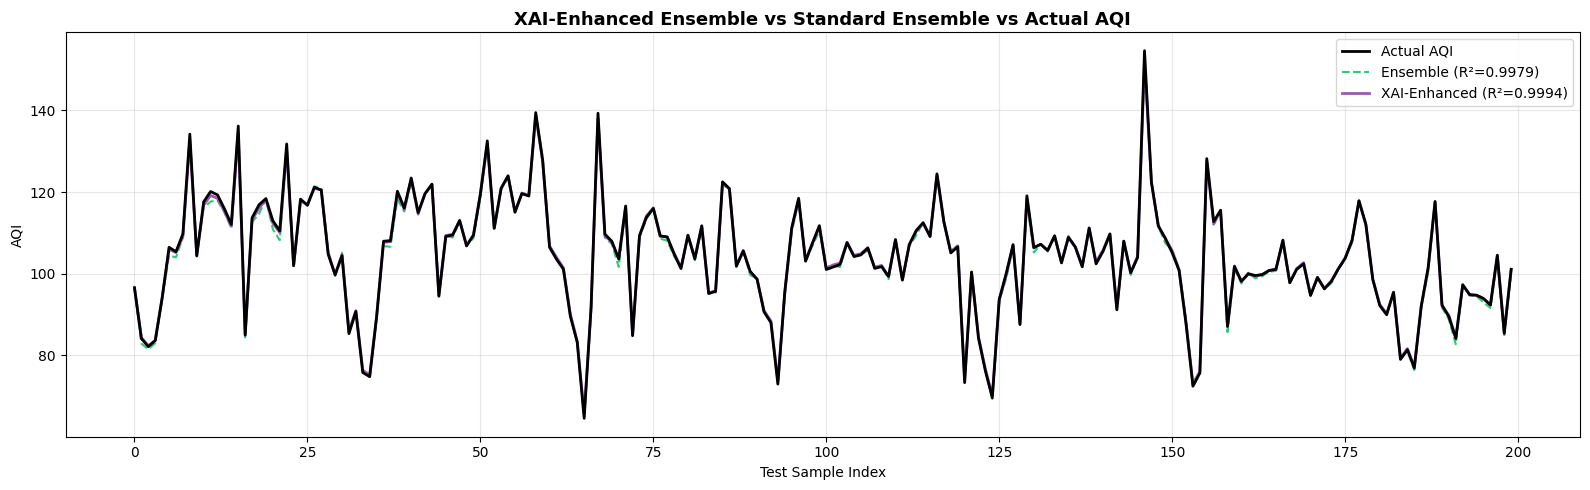

 XAI ensemble comparison plot saved!


In [32]:
# XAI-Enhanced vs Standard Ensemble — Prediction line plot
n_show = min(200, len(y_test))
idx = np.arange(n_show)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(idx, y_test[:n_show],                color='black',   linewidth=2,   label='Actual AQI',              zorder=5)
ax.plot(idx, y_pred_ensemble[:n_show],        color='#2ecc71', linewidth=1.5, label=f'Ensemble (R²={r2_ens:.4f})',     linestyle='--')
ax.plot(idx, y_pred_ensemble_xai[:n_show],    color='#9b59b6', linewidth=2,   label=f'XAI-Enhanced (R²={r2_ens_xai:.4f})', zorder=4)

ax.set_title('XAI-Enhanced Ensemble vs Standard Ensemble vs Actual AQI', fontsize=13, fontweight='bold')
ax.set_xlabel('Test Sample Index')
ax.set_ylabel('AQI')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xai_ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" XAI ensemble comparison plot saved!")



```
# This is formatted as code
```

## Step 12: AQI Category Classification

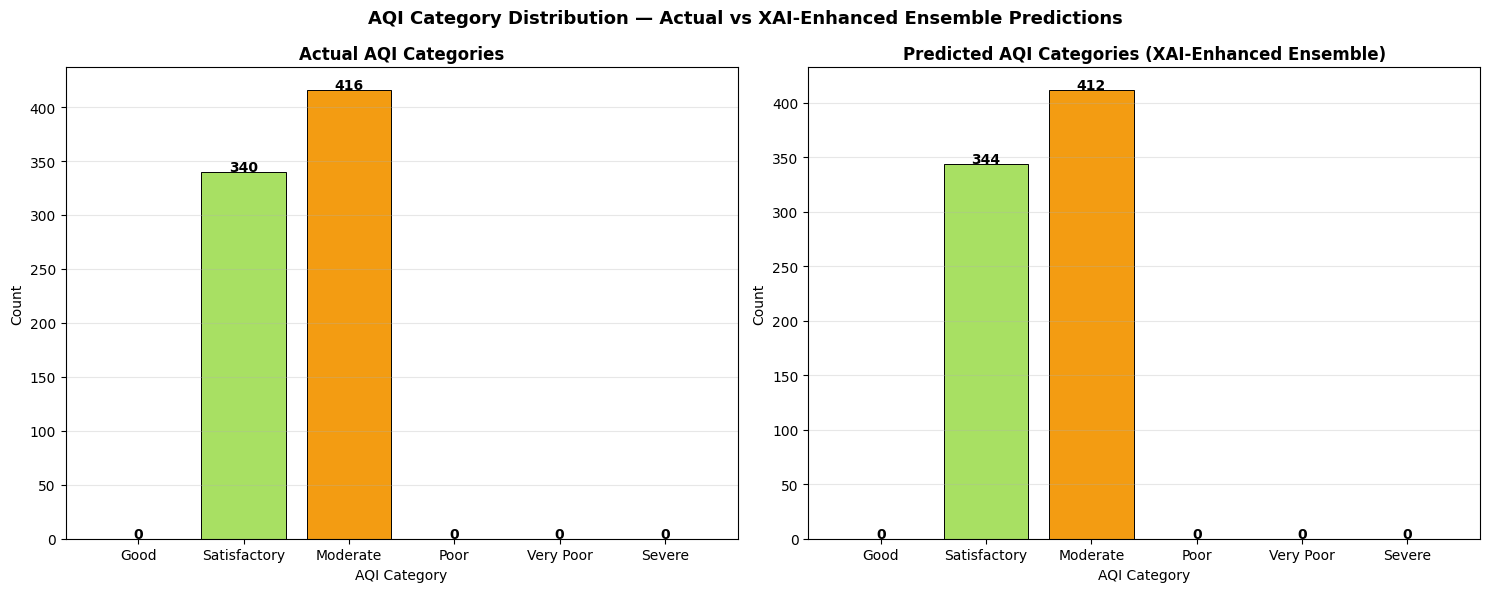

 AQI category distribution saved!


In [33]:
def classify_aqi(aqi_val):
    """Classify AQI into Indian CPCB categories."""
    if aqi_val <= 50:   return 'Good'
    elif aqi_val <= 100: return 'Satisfactory'
    elif aqi_val <= 200: return 'Moderate'
    elif aqi_val <= 300: return 'Poor'
    elif aqi_val <= 400: return 'Very Poor'
    else:                return 'Severe'

aqi_categories   = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
category_colors  = ['#2ecc71', '#a8e063', '#f39c12', '#e74c3c', '#8e44ad', '#2c3e50']

actual_cats   = [classify_aqi(v) for v in y_test]
pred_ens_cats = [classify_aqi(v) for v in y_pred_ensemble_xai]

actual_counts = pd.Series(actual_cats).value_counts().reindex(aqi_categories, fill_value=0)
pred_counts   = pd.Series(pred_ens_cats).value_counts().reindex(aqi_categories, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('AQI Category Distribution — Actual vs XAI-Enhanced Ensemble Predictions',
             fontsize=13, fontweight='bold')

axes[0].bar(aqi_categories, actual_counts, color=category_colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Actual AQI Categories', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('AQI Category')
axes[0].grid(alpha=0.3, axis='y')
for i, (cat, val) in enumerate(zip(aqi_categories, actual_counts)):
    axes[0].text(i, val + 0.5, str(val), ha='center', fontweight='bold')

axes[1].bar(aqi_categories, pred_counts, color=category_colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('Predicted AQI Categories (XAI-Enhanced Ensemble)', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('AQI Category')
axes[1].grid(alpha=0.3, axis='y')
for i, (cat, val) in enumerate(zip(aqi_categories, pred_counts)):
    axes[1].text(i, val + 0.5, str(val), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('aqi_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" AQI category distribution saved!")

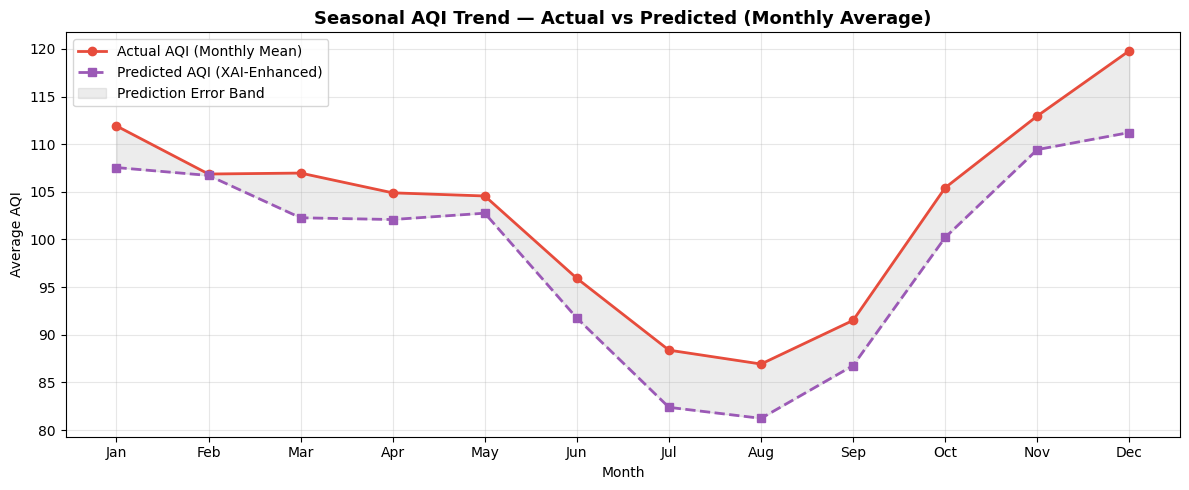

 Seasonal AQI trend plot saved!


In [34]:
# Seasonal AQI trend
df_feat['AQI_pred_xai'] = np.nan
df_feat.loc[df_feat.index[-len(y_pred_ensemble_xai):], 'AQI_pred_xai'] = y_pred_ensemble_xai

monthly_actual = df_feat.groupby('month')['AQI'].mean()
monthly_pred   = df_feat.groupby('month')['AQI_pred_xai'].mean()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1,13), monthly_actual,  marker='o', color='#e74c3c', linewidth=2, label='Actual AQI (Monthly Mean)')
ax.plot(range(1,13), monthly_pred,    marker='s', color='#9b59b6', linewidth=2, label='Predicted AQI (XAI-Enhanced)', linestyle='--')
ax.fill_between(range(1,13), monthly_actual, monthly_pred, alpha=0.15, color='gray', label='Prediction Error Band')
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)
ax.set_title('Seasonal AQI Trend — Actual vs Predicted (Monthly Average)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average AQI')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('seasonal_aqi_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Seasonal AQI trend plot saved!")

## Step 13: Final Results Summary

In [35]:
# Final comprehensive results table
final_results = pd.DataFrame({
    'Model': [
        'LSTM (Baseline)',
        'XGBoost (Baseline)',
        'Ensemble (LSTM + XGBoost)',
        'XAI-Enhanced Ensemble (SHAP-guided)'
    ],
    'RMSE':  [rmse_lstm,    rmse_xgb,  rmse_ens,    rmse_ens_xai],
    'MAE':   [mae_lstm,     mae_xgb,   mae_ens,     mae_ens_xai],
    'R²':    [r2_lstm,      r2_xgb,    r2_ens,      r2_ens_xai],
    'XAI':   ['No', 'No', 'No', 'SHAP + Temporal Sensitivity']
})

print("\n" + "="*85)
print("                    FINAL EXPERIMENTAL RESULTS SUMMARY")
print("="*85)
print(final_results.to_string(index=False))
print("="*85)

# Improvement analysis
rmse_improve = ((rmse_lstm - rmse_ens_xai) / rmse_lstm * 100)
mae_improve  = ((mae_lstm  - mae_ens_xai)  / mae_lstm  * 100)
r2_improve   = ((r2_ens_xai - r2_lstm)     / abs(r2_lstm) * 100)

print(f"\n📈 IMPROVEMENT: XAI-Enhanced Ensemble vs LSTM Baseline")
print(f"   RMSE reduced by : {rmse_improve:+.2f}%")
print(f"   MAE  reduced by : {mae_improve:+.2f}%")
print(f"   R²   improved by: {r2_improve:+.2f}%")


                    FINAL EXPERIMENTAL RESULTS SUMMARY
                              Model     RMSE      MAE       R²                         XAI
                    LSTM (Baseline) 1.197726 0.950723 0.994152                          No
                 XGBoost (Baseline) 0.810951 0.573019 0.997319                          No
          Ensemble (LSTM + XGBoost) 0.719269 0.558210 0.997891                          No
XAI-Enhanced Ensemble (SHAP-guided) 0.381060 0.263462 0.999408 SHAP + Temporal Sensitivity

📈 IMPROVEMENT: XAI-Enhanced Ensemble vs LSTM Baseline
   RMSE reduced by : +68.18%
   MAE  reduced by : +72.29%
   R²   improved by: +0.53%


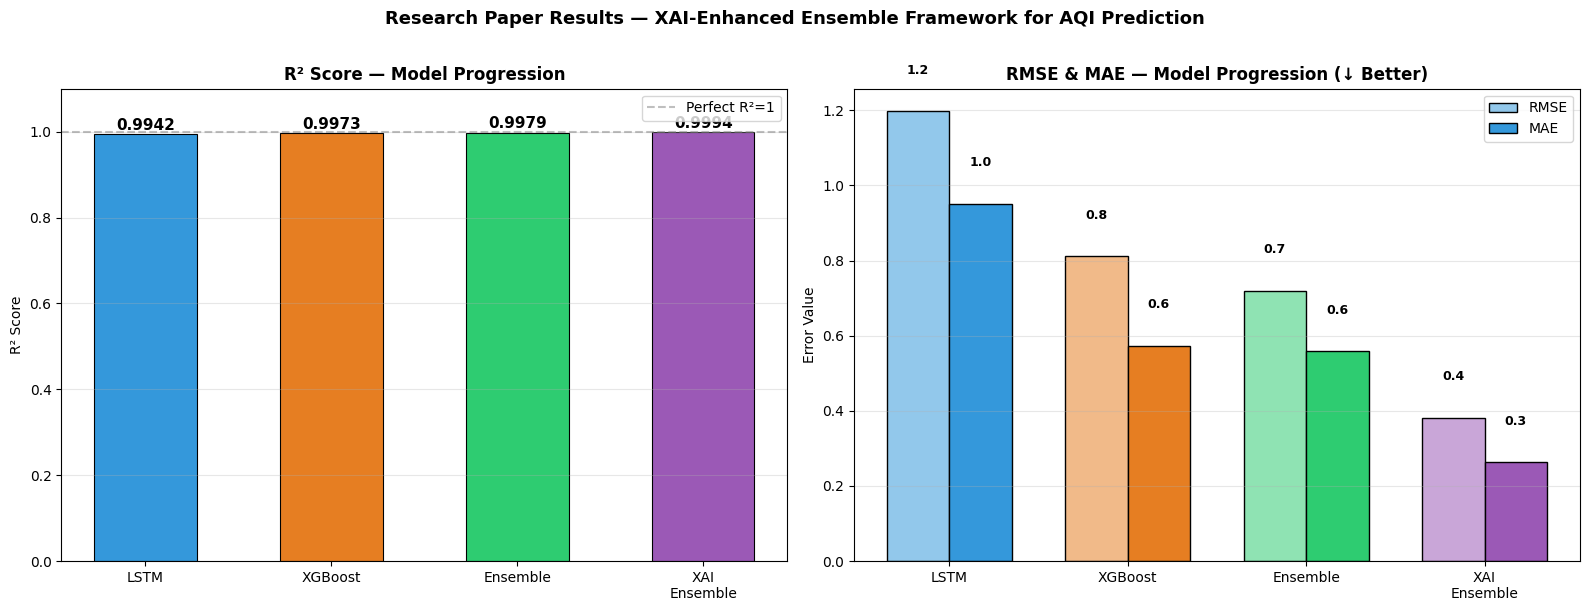

 Final results summary chart saved!


In [36]:
# Final summary visualization — radar chart style metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Research Paper Results — XAI-Enhanced Ensemble Framework for AQI Prediction',
             fontsize=13, fontweight='bold', y=1.01)

# Left: R² comparison
model_labels = ['LSTM', 'XGBoost', 'Ensemble', 'XAI\nEnsemble']
r2_values    = [r2_lstm, r2_xgb, r2_ens, r2_ens_xai]
bar_cols     = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

bars0 = axes[0].bar(model_labels, r2_values, color=bar_cols, edgecolor='black', linewidth=0.8, width=0.55)
axes[0].set_title('R² Score — Model Progression', fontweight='bold', fontsize=12)
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.1)
axes[0].grid(alpha=0.3, axis='y')
axes[0].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect R²=1')
axes[0].legend()
for bar, val in zip(bars0, r2_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)

# Right: Error metrics side-by-side
x = np.arange(len(model_labels))
width = 0.35
bars1 = axes[1].bar(x - width/2, [rmse_lstm, rmse_xgb, rmse_ens, rmse_ens_xai],
                    width, label='RMSE', color=[c + '88' for c in ['#3498db','#e67e22','#2ecc71','#9b59b6']], edgecolor='black')
bars2 = axes[1].bar(x + width/2, [mae_lstm, mae_xgb, mae_ens, mae_ens_xai],
                    width, label='MAE',  color=['#3498db','#e67e22','#2ecc71','#9b59b6'], edgecolor='black')
axes[1].set_title('RMSE & MAE — Model Progression (↓ Better)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Error Value')
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_labels)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')
for bar in list(bars1) + list(bars2):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('final_results_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Final results summary chart saved!")